In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats



In [ ]:
#agregar dataset de contratos
df_contratos = pd.read_csv(r'C:\Users\Gaming\Desktop\data science\TareaData-science\data\2011\contratos.csv', index_col=False)
#agregar dataset de licitaciones
df = pd.read_csv(r'C:\Users\Gaming\Desktop\data science\TareaData-science\data\2011\records.csv', index_col=False)
#cada licitacion se puede dividir en lotes
df_lots = pd.read_csv(r'C:\Users\Gaming\Desktop\data science\TareaData-science\data\2011\ten_lots.csv', index_col=False)
#para saber en que se gasto/construye
df_items = pd.read_csv(r'C:\Users\Gaming\Desktop\data science\TareaData-science\data\2011\ten_items.csv', index_col=False)


In [9]:
variables_utiles_contratos = ['buyer.name','contracts.dateSigned','contracts.period.durationInDays','contracts.value.amount','contracts.value.currency','ocid']
df_contratos = df_contratos[variables_utiles_contratos]

variables_utiles_lots = ['compiledRelease/tender/id', 'compiledRelease/tender/lots/0/id', 'compiledRelease/tender/lots/0/title','compiledRelease/tender/lots/0/value/amount', 'compiledRelease/tender/lots/0/value/currency']
df_lots = df_lots[variables_utiles_lots]

variables_utiles_items = ['compiledRelease/tender/id', 'compiledRelease/tender/items/0/id', 'compiledRelease/tender/items/0/description', 'compiledRelease/tender/items/0/quantity', 'compiledRelease/tender/items/0/unit/name', 'compiledRelease/tender/items/0/unit/value/amount', 'compiledRelease/tender/items/0/unit/value/currency','compiledRelease/tender/items/0/relatedLot']
df_items = df_items[variables_utiles_items]

In [29]:
# 1. Renombrar df_contratos
df_contratos = df_contratos.rename(columns={
    'buyer.name': 'nombre_comprador',             
    'contracts.dateSigned': 'fecha_firma_contrato',
    'contracts.period.durationInDays': 'duracion_contrato_dias',  
    'contracts.value.amount': 'monto_contrato',
    'contracts.value.currency': 'moneda_contrato',
    'ocid': 'ocid'                               
})

# 2. Renombrar df_lots (Lotes)
df_lots = df_lots.rename(columns={
    'compiledRelease/tender/id': 'id_licitacion',   
    'compiledRelease/tender/lots/0/id': 'id_lote',
    'compiledRelease/tender/lots/0/title': 'titulo_lote',
    'compiledRelease/tender/lots/0/value/amount': 'monto_lote',
    'compiledRelease/tender/lots/0/value/currency': 'moneda_lote'
})

# 3. Renombrar df_items (Ítems)
df_items = df_items.rename(columns={
    'compiledRelease/tender/id': 'id_licitacion',  
    'compiledRelease/tender/items/0/id': 'id_item',
    'compiledRelease/tender/items/0/description': 'descripcion_item',
    'compiledRelease/tender/items/0/quantity': 'cantidad_item',
    'compiledRelease/tender/items/0/unit/name': 'unidad_medida_item',
    'compiledRelease/tender/items/0/unit/value/amount': 'monto_unitario_item',
    'compiledRelease/tender/items/0/unit/value/currency': 'moneda_item',
    'compiledRelease/tender/items/0/relatedLot': 'id_lote_relacionado'
})

In [ ]:


def datos_estadisticos(serie):
    """
    Recibe una Serie de Pandas y retorna sus estadísticas resumen.
    """
    serie_limpia = serie.dropna()
    return pd.Series({
        'Nombre Columna': serie.name,
        'Tipo de Dato': serie.dtype,
        'Valores Nulos': serie.isnull().sum(),
        'Valores Únicos': serie.nunique(),
        'Valor Mínimo': serie.min(),
        'Valor Máximo': serie.max(),
        'Media': serie.mean(),
        'Mediana': serie.median(),
        'Desviación Estándar': serie.std(),
        'Cuartiles': np.quantile(serie_limpia, [0.05,0.25, 0.5, 0.75,0.95])
    })

# Llamada a cada columna desde su DataFrame correspondiente
columnas_a_analizar = [
    df_contratos['duracion_dias'],
    df_contratos['monto_contrato'],
    df_lots['monto_lote'],
    df_items['precio_unitario'],
    df_items['cantidad']
]

# Recorremos y mostramos las estadísticas de cada una
for col in columnas_a_analizar:
    print(datos_estadisticos(col))
    print("-" * 40)

Nombre Columna                             duracion_dias
Tipo de Dato                                     float64
Valores Nulos                                        501
Valores Únicos                                       220
Valor Mínimo                                         0.0
Valor Máximo                                     11315.0
Media                                         203.168738
Mediana                                            180.0
Desviación Estándar                           285.360048
Cuartiles              [15.0, 60.0, 180.0, 270.0, 540.0]
dtype: object
----------------------------------------
Nombre Columna                                            monto_contrato
Tipo de Dato                                                       int64
Valores Nulos                                                          0
Valores Únicos                                                      7069
Valor Mínimo                                                        6768
Valor Máxi

# Medidas de distribucion o de forma

In [38]:
def forma_distribucion(serie):
    """
    Recibe una Serie de Pandas y retorna la asimetría y curtosis.
    """
    serie_limpia = serie.dropna()
    asimetria = stats.skew(serie_limpia, bias=False)
    curtosis = stats.kurtosis(serie_limpia, bias=False)
    
    return pd.Series({
        'Nombre Columna': serie.name,
        'Asimetría': asimetria,
        'Curtosis': curtosis
    })


for i in columnas_a_analizar:
    print(f'La asimetria es:{forma_distribucion(i)["Asimetría"]} y la curtosis es: {forma_distribucion(i)["Curtosis"]}')


La asimetria es:24.137646367458963 y la curtosis es: 885.0273673106456
La asimetria es:27.72694204735616 y la curtosis es: 975.724529486627
La asimetria es:227.83535289053006 y la curtosis es: 55901.36980593291
La asimetria es:425.9970791427969 y la curtosis es: 184740.54938062522
La asimetria es:100.4739375757618 y la curtosis es: 13890.406224486747


In [41]:
df_contratos.columns

Index(['comprador_nombre', 'fecha_firma_contrato', 'duracion_dias',
       'monto_contrato', 'moneda_contrato', 'id_licitacion_ocid'],
      dtype='object')

# Análisis Bivariado

# Comparación entre númerica y númerica

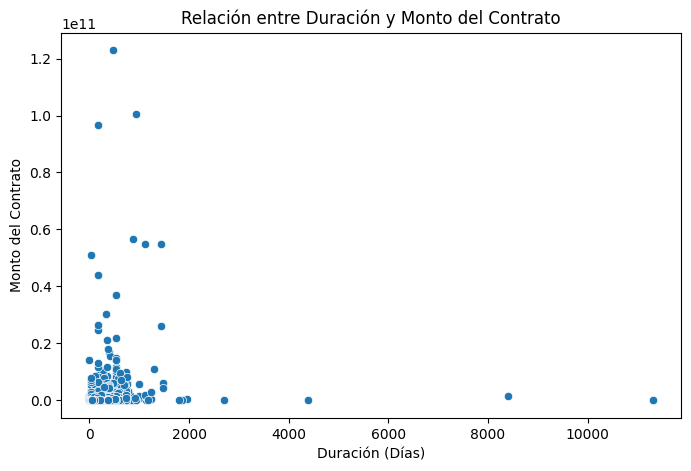

Correlación de Pearson:
                 duracion_dias  monto_contrato
duracion_dias        1.000000        0.088125
monto_contrato       0.088125        1.000000

Correlación de Spearman:
                 duracion_dias  monto_contrato
duracion_dias        1.000000        0.279485
monto_contrato       0.279485        1.000000


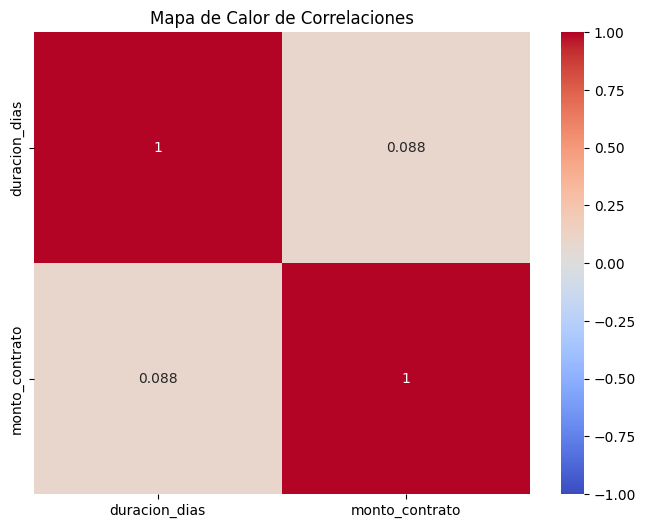

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Analizar este par monto del contrato y duracion de dias nos permite evaluar si las compras del Estado siguen una
#  proporcionalidad lógica entre presupuesto y tiempo, o si existen anomalías, por ejemplo: contratos millonarios
#  con plazos sospechosamente cortos.
# 1. Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_contratos, x='duracion_dias', y='monto_contrato')
plt.title('Relación entre Duración y Monto del Contrato')
plt.xlabel('Duración (Días)')
plt.ylabel('Monto del Contrato')
plt.show()

# 2. Correlaciones de Pearson y Spearman
pearson_corr = df_contratos[['duracion_dias', 'monto_contrato']].dropna().corr(method='pearson')
spearman_corr = df_contratos[['duracion_dias', 'monto_contrato']].dropna().corr(method='spearman')

print("Correlación de Pearson:\n", pearson_corr)
print("\nCorrelación de Spearman:\n", spearman_corr)

# 3. Matriz de Correlaciones en Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
matriz_corr = df_contratos[['duracion_dias', 'monto_contrato']].dropna().corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

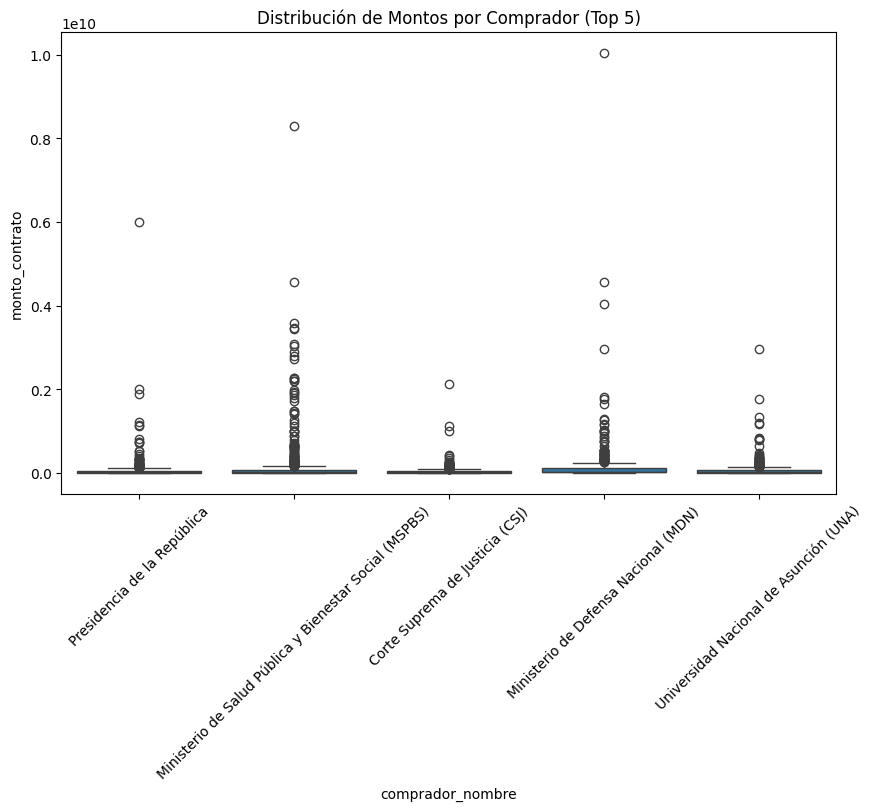

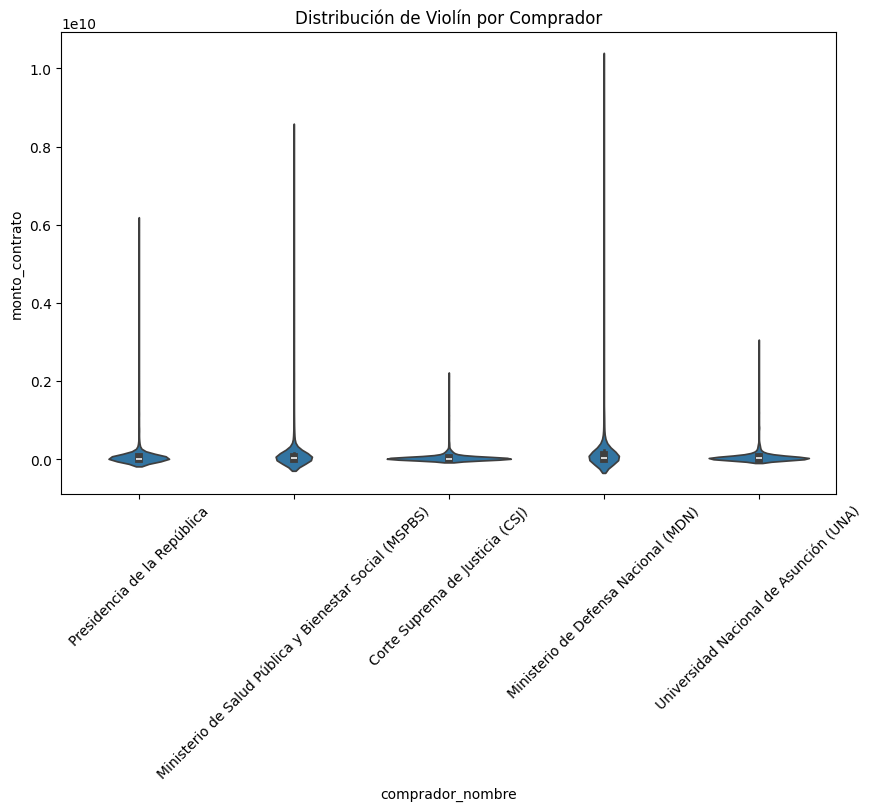

                                                    conteo         media  \
comprador_nombre                                                           
Ministerio de Salud Pública y Bienestar Social ...     735  1.596708e+08   
Universidad Nacional de Asunción (UNA)                 661  6.406864e+07   
Presidencia de la República                            498  7.145185e+07   
Ministerio de Defensa Nacional (MDN)                   465  1.589842e+08   
Corte Suprema de Justicia (CSJ)                        416  4.567076e+07   
Administración Nacional de Electricidad (ANDE)         359  8.181334e+08   
Ministerio del Interior (M.I.)                         221  5.765836e+08   
Ministerio de Educación y Ciencias (MEC)               219  6.466329e+08   
Ministerio de Justicia  (MJ)                           208  1.869390e+08   
Ministerio Público - Fiscalía (FGE)                    207  1.112993e+08   

                                                        mediana  \
comprador_nombre    

In [ ]:
# Esta comparacion, a nuestra criterio, nos permite identificar que instituciones concentran presupuestos altos y cuales tienen un comportamiento
# de gasto más volatil o disperso.

# Filtramos los 5 compradores principales para que el gráfico sea legible
top_compradores = df_contratos['comprador_nombre'].value_counts().head(5).index
df_top = df_contratos[df_contratos['comprador_nombre'].isin(top_compradores)]

# 1. Diagrama de Caja (Boxplot) por Grupo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top, x='comprador_nombre', y='monto_contrato')
plt.xticks(rotation=45)
plt.title('Distribución de Montos por Comprador (Top 5)')
plt.show()

# 2. Diagrama de Violín
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_top, x='comprador_nombre', y='monto_contrato')
plt.xticks(rotation=45)
plt.title('Distribución de Violín por Comprador')
plt.show()

# 3. Tabla de Estadísticos Resumen por Categoría
est_por_comprador = df_contratos.groupby('comprador_nombre')['monto_contrato'].agg(
    conteo='count',
    media='mean',
    mediana='median',
    desviacion_std='std',
    minimo='min',
    maximo='max'
).sort_values(by='conteo', ascending=False)

print(est_por_comprador.head(10))

In [49]:
# 1. Tabla de Contingencia - Frecuencias Absolutas
tabla_contingencia = pd.crosstab(
    df_contratos['comprador_nombre'], 
    df_contratos['moneda_contrato']
)
print("Frecuencias Absolutas:\n", tabla_contingencia.head(10))

# 2. Frecuencias Relativas por Fila (porcentaje dentro de cada comprador)
por_fila = pd.crosstab(
    df_contratos['comprador_nombre'], 
    df_contratos['moneda_contrato'], 
    normalize='index'
) * 100
print("\nPorcentaje por Fila (%):\n", por_fila.head(10))

# 3. Frecuencias Relativas por Columna (porcentaje dentro de cada moneda)
por_columna = pd.crosstab(
    df_contratos['comprador_nombre'], 
    df_contratos['moneda_contrato'], 
    normalize='columns'
) * 100
print("\nPorcentaje por Columna (%):\n", por_columna.head(10))

Frecuencias Absolutas:
 moneda_contrato                                     PYG  USD
comprador_nombre                                            
Administración Nacional de Electricidad (ANDE)      346   13
Administración Nacional de Navegación y Puertos...   36    0
Ag. Nac. de Eval. y Acreditación de la Educació...   15    0
Agencia Financiera de Desarrollo (AFD)               11    0
Banco Central del Paraguay (BCP)                    132    0
Banco Nacional de Fomento (BNF)                      51    0
Caja de Jubilaciones y Pensiones de Empleados d...   25    0
Caja de Jubilaciones y Pensiones del Personal M...   31    0
Caja de Jubilaciones y Pensiones del Personal d...   38    0
Caja de Seguridad Social de Empleados y Obreros...    3    0

Porcentaje por Fila (%):
 moneda_contrato                                           PYG      USD
comprador_nombre                                                      
Administración Nacional de Electricidad (ANDE)       96.37883  3.62117
Admi

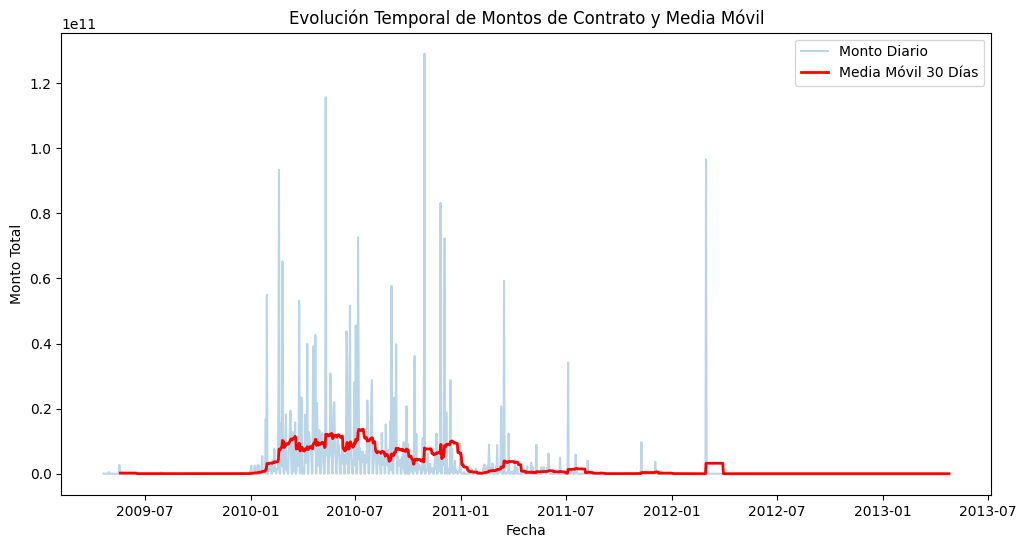

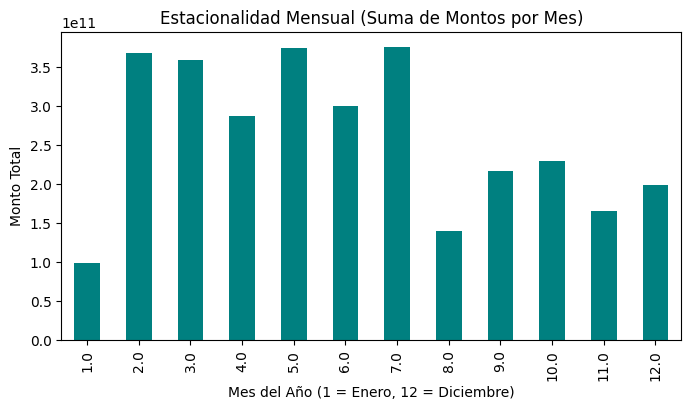

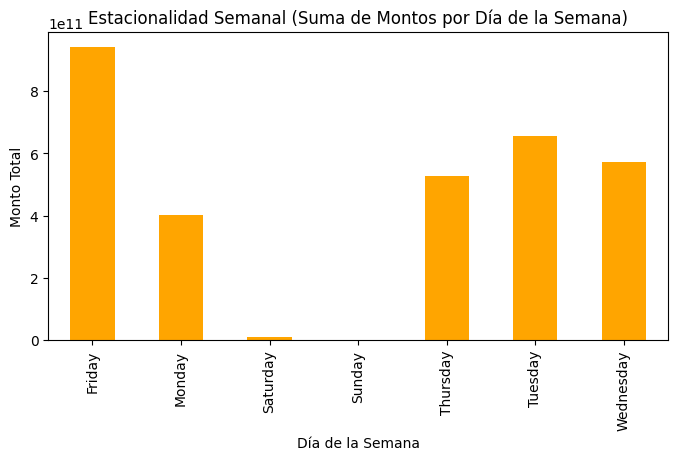

In [50]:
# Preparación de la variable temporal
df_contratos['fecha_firma_contrato'] = pd.to_datetime(df_contratos['fecha_firma_contrato'], errors='coerce')

# Creamos una serie temporal agrupadando montos por día
df_tiempo = df_contratos.dropna(subset=['fecha_firma_contrato']).set_index('fecha_firma_contrato')
serie_diaria = df_tiempo['monto_contrato'].resample('D').sum().fillna(0)

# 1. Media Móvil (ejemplo: a 30 días)
media_movil_30d = serie_diaria.rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(serie_diaria.index, serie_diaria, label='Monto Diario', alpha=0.3)
plt.plot(media_movil_30d.index, media_movil_30d, label='Media Móvil 30 Días', color='red', linewidth=2)
plt.title('Evolución Temporal de Montos de Contrato y Media Móvil')
plt.xlabel('Fecha')
plt.ylabel('Monto Total')
plt.legend()
plt.show()

# 2. Estacionalidad Mensual
df_contratos['mes'] = df_contratos['fecha_firma_contrato'].dt.month
monto_por_mes = df_contratos.groupby('mes')['monto_contrato'].sum()

plt.figure(figsize=(8, 4))
monto_por_mes.plot(kind='bar', color='teal')
plt.title('Estacionalidad Mensual (Suma de Montos por Mes)')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Monto Total')
plt.show()

# 3. Estacionalidad Semanal
df_contratos['dia_semana'] = df_contratos['fecha_firma_contrato'].dt.day_name()
monto_por_dia = df_contratos.groupby('dia_semana')['monto_contrato'].sum()

plt.figure(figsize=(8, 4))
monto_por_dia.plot(kind='bar', color='orange')
plt.title('Estacionalidad Semanal (Suma de Montos por Día de la Semana)')
plt.xlabel('Día de la Semana')
plt.ylabel('Monto Total')
plt.show()